In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('esl_pred_v2.csv',index_col=0)
idx_1 = df['esl_label'].values != df['label'].values 
print(idx_1.sum())

idx_2= df['esl_psc_label'].values != df['label'].values 
print(idx_2.sum())

print(df['species_cn'][idx_1])
print(df['species_cn'][idx_2])

8
5
Pteropus_giganteus     印度狐蝠
Pteropus_alecto         黑狐蝠
ZWS                     猪尾鼠
Echinops_telfairi      小马岛猬
Pteropus_vampyrus     马来大狐蝠
Sorex_araneus          普通鼩鼱
shrew_mole               鼩鼹
Physeter_catodon        抹香鲸
Name: species_cn, dtype: object
Panthera_tigris_altaica     东北虎
Echinops_telfairi          小马岛猬
Rousettus_aegyptiacus      埃及果蝠
Sorex_araneus              普通鼩鼱
shrew_mole                   鼩鼹
Name: species_cn, dtype: object


In [19]:
df_col = ['印度狐蝠','黑狐蝠','马来大狐蝠','大蹄蝠',
          '大菊头蝠','埃及果蝠',  '小须鲸',
          '抹香鲸', '东北虎', '科氏冕狐猴', '猪尾鼠',
          '星鼻鼹','鼩鼹','普通鼩鼱','开普金鼹','亚洲象', '小马岛猬']
eco_label = [0,0,0,1,1,1,0,1,0,0,1,0,1,1,0,0,1]

error_case = {
    'CEP': ['抹香鲸','星鼻鼹','开普金鼹', '普通鼩鼱'],
    'ESL': ['印度狐蝠','黑狐蝠','马来大狐蝠','抹香鲸','鼩鼹','普通鼩鼱',
             '猪尾鼠','小马岛猬'],
    'ESL-PSC': ['东北虎','埃及果蝠', 
                '鼩鼹','普通鼩鼱','小马岛猬'],
    'CEP_w/o_cs': ['抹香鲸', '猪尾鼠', '星鼻鼹', '小马岛猬'],
    'CEP_w/o_fs': ['大菊头蝠', '埃及果蝠', '小须鲸', '抹香鲸', '科氏冕狐猴',
                '猪尾鼠', '鼩鼹', '普通鼩鼱', '亚洲象', '小马岛猬'],
    'Random Forest': ['大蹄蝠', '抹香鲸', '猪尾鼠', '星鼻鼹', '小马岛猬'],
    'Logistic Regression': ['埃及果蝠', '东北虎', '猪尾鼠', '鼩鼹', '普通鼩鼱', '小马岛猬'],
    'Naive Bayes': ['埃及果蝠', '抹香鲸', '东北虎', '普通鼩鼱', '小马岛猬'],
    'SVM': ['埃及果蝠', '抹香鲸', '猪尾鼠', '鼩鼹', '普通鼩鼱', '小马岛猬']
}

n = len(error_case)
p = len(df_col)
x = np.zeros(shape = (n,p))
df = pd.DataFrame(x, columns = df_col, index = list(error_case.keys()))
for idx in df.index:
    for col in df.columns:
        if col in error_case[idx]:
            df.loc[idx,col] = 0
        else:
            df.loc[idx,col] = 1

In [20]:
meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col = 0)
tmp = dict(meta_df.loc[:,'species_chinese']) 
species_map = {tmp[key]: key for key in tmp}
df.columns = df.columns.map(species_map)
df.head()

,Pteropus_giganteus,Pteropus_alecto,Pteropus_vampyrus,Hipposideros_armiger,Rhinolophus_ferrumequinum,Rousettus_aegyptiacus,Balaenoptera_acutorostrata_scammoni,Physeter_catodon,Panthera_tigris_altaica,Propithecus_coquereli,ZWS,Condylura_cristata,shrew_mole,Sorex_araneus,Chrysochloris_asiatica,Elephas_maximus_indicus,Echinops_telfairi
CEP,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
ESL,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
ESL-PSC,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
CEP_w/o_cs,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
CEP_w/o_fs,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [21]:
idx = meta_df['label'] != 2
eval_id = meta_df.loc[idx,:].index 
print(len(eval_id))
labels = meta_df.loc[idx,'label'].values 

x = np.repeat(labels.reshape(1,104), 10, axis = 0)
pred_df = pd.DataFrame(x,index = list(df.index) + ['label'], columns = eval_id)
for key in df.index:
    for key_1 in df.columns:
        if df.loc[key, key_1] == 0 and pred_df.loc['label', key_1] == 1:
            pred_df.loc[key, key_1] = 0 
        if df.loc[key, key_1] == 0 and pred_df.loc['label', key_1] == 0:
            pred_df.loc[key, key_1] = 1 
''' eval ''' 

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
res = {}
for ele in pred_df.index: 
    x = pred_df.loc[ele,:].values 
    y = pred_df.loc['label',:].values 
    
    f1 = f1_score(y,x)
    pre = precision_score(y,x)
    rec = recall_score(y,x)
    acc = accuracy_score(y,x)
    res[ele] = [f1,pre,rec,acc] 
    
eval_df = pd.DataFrame(res, index = ['F1','Precision','Recall','Accuracy'])
eval_df
    

104


,CEP,ESL,ESL-PSC,CEP_w/o_cs,CEP_w/o_fs,Random Forest,Logistic Regression,Naive Bayes,SVM,label
F1,0.933333,0.862069,0.912281,0.931034,0.821429,0.912281,0.892857,0.912281,0.888889,1.0
Precision,0.933333,0.892857,0.962963,0.964286,0.884615,0.962963,0.961538,0.962963,1.000000,1.0
Recall,0.933333,0.833333,0.866667,0.900000,0.766667,0.866667,0.833333,0.866667,0.800000,1.0
Accuracy,0.961538,0.923077,0.951923,0.961538,0.903846,0.951923,0.942308,0.951923,0.942308,1.0


## CEP 消融评估

In [22]:
raw_df = df.copy()

/tmp/ipykernel_2043659/1959132233.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


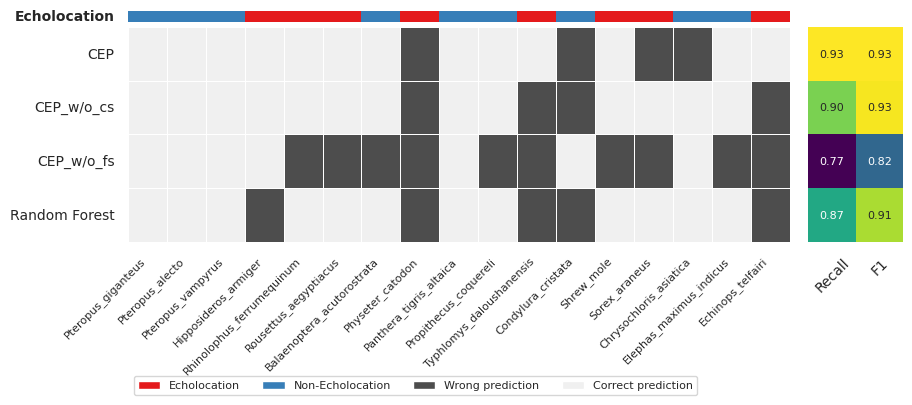

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


metrics_df =   eval_df.loc[:,['CEP', 'CEP_w/o_cs', 'CEP_w/o_fs', 'Random Forest']].T  #pd.DataFrame({'Recall': eval_df}, index=methods)
true_labels = np.array(eco_label)

df = raw_df.loc[['CEP', 'CEP_w/o_cs', 'CEP_w/o_fs', 'Random Forest'],:]
methods = df.index
df = df.rename(columns={'ZWS': 'Typhlomys_daloushanensis',
                        'Balaenoptera_acutorostrata_scammoni': 'Balaenoptera_acutorostrata',
                        'shrew_mole': 'Shrew_mole'})


# 3. 开始绘图
# 设置整体风格：白色背景，无边框
sns.set_theme(style="white")
fig = plt.figure(figsize=(10, 3))

# 使用 GridSpec 分割区域：[1: 顶部的label, 2: 主热图, 3: 右侧指标]
gs = plt.GridSpec(2, 2, width_ratios=[14, 2], height_ratios=[0.5, 10], hspace=0.05, wspace=0.05)

# --- A. 顶部 Color Bar (展示物种真实 Label) ---
ax_col_colors = fig.add_subplot(gs[0, 0])
# 红色代表1, 蓝色代表0
cmap_label = ListedColormap(['#377eb8', '#e41a1c']) 
sns.heatmap([true_labels], ax=ax_col_colors, cbar=False, cmap=cmap_label, 
            xticklabels=False, yticklabels=['Label'])
ax_col_colors.set_yticks([0.5])
ax_col_colors.set_yticklabels(['Echolocation'], rotation=0, fontsize=10, fontweight='bold')

# --- B. 主热图 (展示预测错误) ---
ax_heatmap = fig.add_subplot(gs[1, 0])
cmap_main = ListedColormap(['#4d4d4d', '#f0f0f0']) 
sns.heatmap(df, ax=ax_heatmap, cbar=False, cmap=cmap_main, 
            linewidths=0.5, linecolor='white', xticklabels=True, yticklabels=True)
# ax_heatmap.set_xlabel("Species", fontsize=12, fontweight='bold')
# ax_heatmap.set_ylabel("Methods", fontsize=12, fontweight='bold')
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize = 8)
ax_heatmap.tick_params(axis='y', labelsize=10)

# --- C. 右侧指标 (Precision & Recall) ---
ax_metrics = fig.add_subplot(gs[1, 1])
sns.heatmap(metrics_df.loc[:,['Recall','F1']], ax=ax_metrics, annot=True, fmt=".2f", cmap="viridis", 
            cbar=False, yticklabels=False, annot_kws={"size": 8})
# ax_metrics.set_xticklabels(['Precision','Recall'], rotation=45)
ax_metrics.set_xticklabels(['Recall','F1'], rotation=45)
ax_metrics.tick_params(axis='x', labelsize=10)
# 添加图例说明
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e41a1c', label='Echolocation'),
    Patch(facecolor='#377eb8', label='Non-Echolocation'),
    Patch(facecolor='#4d4d4d', label='Wrong prediction'),
    Patch(facecolor='#f0f0f0', label='Correct prediction')
]
ax_heatmap.legend(handles=legend_elements, bbox_to_anchor=(0, -0.6), 
                  loc='upper left', ncol=4, frameon=True, prop={'size': 8})

plt.tight_layout()
plt.savefig('ablation_eval_plot.svg', bbox_inches='tight')
plt.show()

## 对比评估

/tmp/ipykernel_2043659/3123870284.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


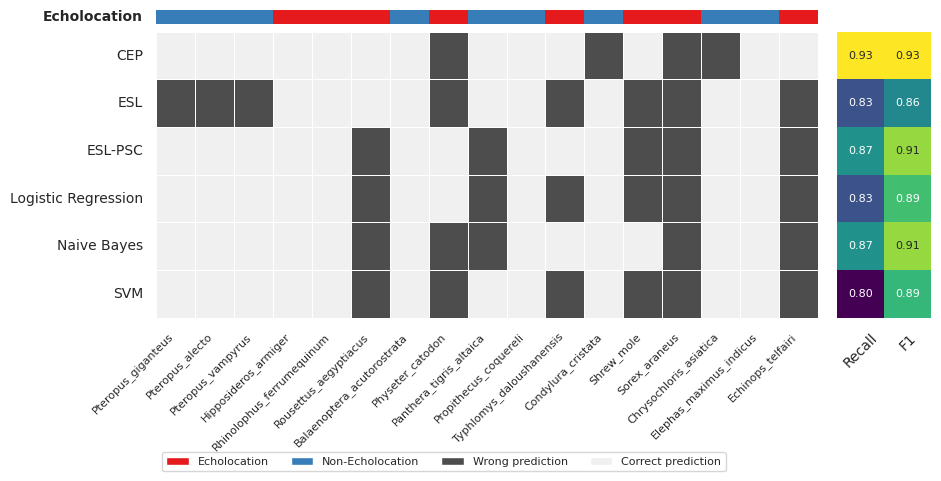

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


metrics_df =   eval_df.loc[:,['CEP','ESL','ESL-PSC','Logistic Regression','Naive Bayes', 'SVM']].T  #pd.DataFrame({'Recall': eval_df}, index=methods)
true_labels = np.array(eco_label)
methods = df.index
df = raw_df.loc[['CEP', 'ESL','ESL-PSC','Logistic Regression','Naive Bayes', 'SVM'],:]
df = df.rename(columns={'ZWS': 'Typhlomys_daloushanensis',
                        'Balaenoptera_acutorostrata_scammoni': 'Balaenoptera_acutorostrata',
                        'shrew_mole': 'Shrew_mole'})


# 3. 开始绘图
# 设置整体风格：白色背景，无边框
sns.set_theme(style="white")
fig = plt.figure(figsize=(10, 4))

# 使用 GridSpec 分割区域：[1: 顶部的label, 2: 主热图, 3: 右侧指标]
gs = plt.GridSpec(2, 2, width_ratios=[14, 2], height_ratios=[0.5, 10], hspace=0.05, wspace=0.05)

# --- A. 顶部 Color Bar (展示物种真实 Label) ---
ax_col_colors = fig.add_subplot(gs[0, 0])
# 红色代表1, 蓝色代表0
cmap_label = ListedColormap(['#377eb8', '#e41a1c']) 
sns.heatmap([true_labels], ax=ax_col_colors, cbar=False, cmap=cmap_label, 
            xticklabels=False, yticklabels=['Label'])
ax_col_colors.set_yticks([0.5])
ax_col_colors.set_yticklabels(['Echolocation'], rotation=0, fontsize=10, fontweight='bold')

# --- B. 主热图 (展示预测错误) ---
ax_heatmap = fig.add_subplot(gs[1, 0])
cmap_main = ListedColormap(['#4d4d4d', '#f0f0f0']) 
sns.heatmap(df, ax=ax_heatmap, cbar=False, cmap=cmap_main, 
            linewidths=0.5, linecolor='white', xticklabels=True, yticklabels=True)
# ax_heatmap.set_xlabel("Species", fontsize=12, fontweight='bold')
# ax_heatmap.set_ylabel("Methods", fontsize=12, fontweight='bold')
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize = 8)
ax_heatmap.tick_params(axis='y', labelsize=10)

# --- C. 右侧指标 (Precision & Recall) ---
ax_metrics = fig.add_subplot(gs[1, 1])
sns.heatmap(metrics_df.loc[:,['Recall','F1']], ax=ax_metrics, annot=True, fmt=".2f", cmap="viridis", 
            cbar=False, yticklabels=False, annot_kws={"size": 8})
# ax_metrics.set_xticklabels(['Precision','Recall'], rotation=45)
ax_metrics.set_xticklabels(['Recall','F1'], rotation=45)
ax_metrics.tick_params(axis='x', labelsize=10)
# 添加图例说明
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e41a1c', label='Echolocation'),
    Patch(facecolor='#377eb8', label='Non-Echolocation'),
    Patch(facecolor='#4d4d4d', label='Wrong prediction'),
    Patch(facecolor='#f0f0f0', label='Correct prediction')
]
ax_heatmap.legend(handles=legend_elements, bbox_to_anchor=(0, -0.45), 
                  loc='upper left', ncol=4, frameon=True, prop={'size': 8})

plt.tight_layout()
plt.savefig('compare_eval_plot.svg', bbox_inches='tight')
plt.show()

## 之前结果

/tmp/ipykernel_2692179/2282102370.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


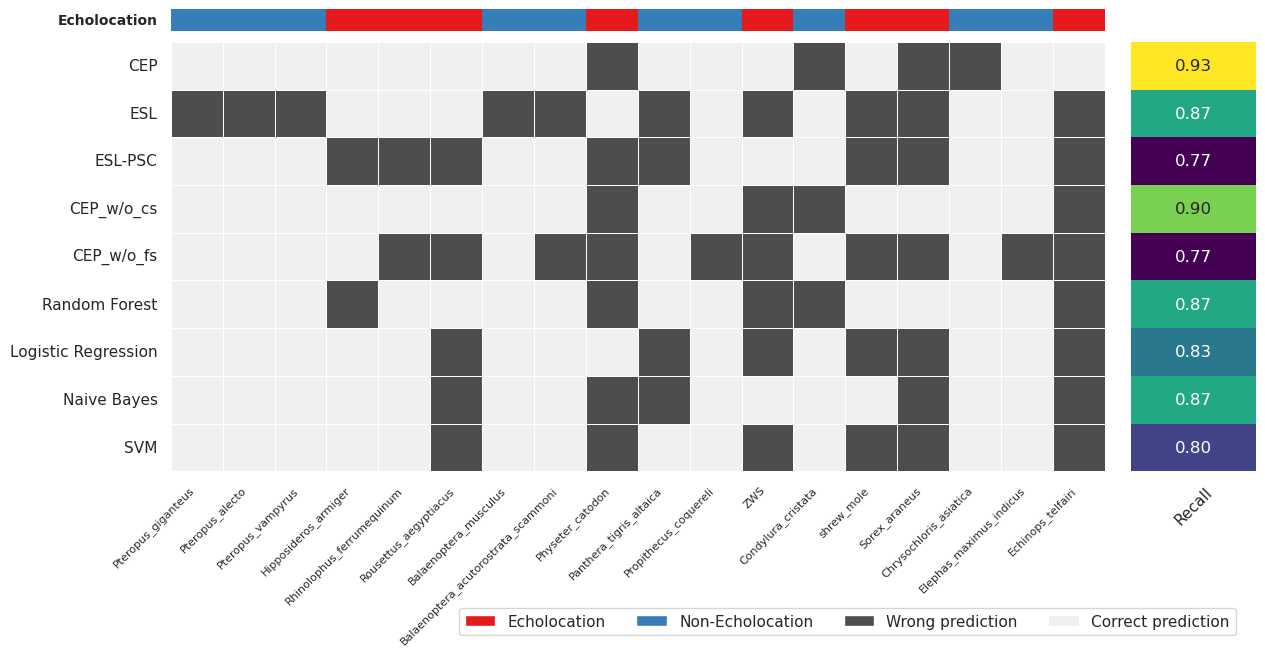

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


true_labels = np.array(eco_label)
methods = df.index

# --- 2. 逻辑修正：计算全局 Precision 和 Recall ---
TOTAL_POS = 30
TOTAL_NEG = 74
# DF外的物种数中，Label为1的数量
pos_outside = TOTAL_POS - np.sum(true_labels == 1)

precision_list = []
recall_list = []

for method in methods:
    # DF内的真阳性 (预测正确且Label为1)
    tp_inside = np.sum((df.loc[method] == 1) & (true_labels == 1))
    
    tp_total = tp_inside + pos_outside
    # 预测为1的总数 = (该行中1的数量) + 94 (DF外全部预测正确)
    predicted_pos_total = np.sum(df.loc[method] == 1) + 86
    
    
    method_preds = []
    for i, val in enumerate(df.loc[method]):
        if val == 1: # 预测正确
            method_preds.append(true_labels[i])
        else: # 预测错误
            method_preds.append(1 - true_labels[i])
            
    tp_final = np.sum((np.array(method_preds) == 1) & (true_labels == 1)) + pos_outside
    fp_final = np.sum((np.array(method_preds) == 1) & (true_labels == 0)) + 0 # DF外无FP
    
    precision_list.append(tp_final / (tp_final + fp_final))
    recall_list.append(tp_final / TOTAL_POS)

metrics_df = pd.DataFrame({'Recall': recall_list}, index=methods)
# metrics_df = pd.DataFrame({'Recall': recall_list}, index=methods)

# 3. 开始绘图
# 设置整体风格：白色背景，无边框
sns.set_theme(style="white")
fig = plt.figure(figsize=(14, 6))

# 使用 GridSpec 分割区域：[1: 顶部的label, 2: 主热图, 3: 右侧指标]
gs = plt.GridSpec(2, 2, width_ratios=[15, 2], height_ratios=[0.5, 10], hspace=0.05, wspace=0.05)

# --- A. 顶部 Color Bar (展示物种真实 Label) ---
ax_col_colors = fig.add_subplot(gs[0, 0])
# 红色代表1, 蓝色代表0
cmap_label = ListedColormap(['#377eb8', '#e41a1c']) 
sns.heatmap([true_labels], ax=ax_col_colors, cbar=False, cmap=cmap_label, 
            xticklabels=False, yticklabels=['Label'])
ax_col_colors.set_yticks([0.5])
ax_col_colors.set_yticklabels(['Echolocation'], rotation=0, fontsize=10, fontweight='bold')

# --- B. 主热图 (展示预测错误) ---
ax_heatmap = fig.add_subplot(gs[1, 0])
cmap_main = ListedColormap(['#4d4d4d', '#f0f0f0']) 
sns.heatmap(df, ax=ax_heatmap, cbar=False, cmap=cmap_main, 
            linewidths=0.5, linecolor='white', xticklabels=True, yticklabels=True)
# ax_heatmap.set_xlabel("Species", fontsize=12, fontweight='bold')
# ax_heatmap.set_ylabel("Methods", fontsize=12, fontweight='bold')
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize = 8)


# --- C. 右侧指标 (Precision & Recall) ---
ax_metrics = fig.add_subplot(gs[1, 1])
sns.heatmap(metrics_df, ax=ax_metrics, annot=True, fmt=".2f", cmap="viridis", 
            cbar=False, yticklabels=False)
# ax_metrics.set_xticklabels(['Precision','Recall'], rotation=45)
ax_metrics.set_xticklabels(['Recall'], rotation=45)
# 添加图例说明
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e41a1c', label='Echolocation'),
    Patch(facecolor='#377eb8', label='Non-Echolocation'),
    Patch(facecolor='#4d4d4d', label='Wrong prediction'),
    Patch(facecolor='#f0f0f0', label='Correct prediction')
]
ax_heatmap.legend(handles=legend_elements, bbox_to_anchor=(0.3, -0.3), 
                  loc='upper left', ncol=4, frameon=True)

plt.tight_layout()
plt.savefig('eval_plot.svg', bbox_inches='tight')
plt.show()

In [18]:
metrics_df

,Precision,Recall
CEP,0,0.0
ESL,0,0.0
ESL-PSC,0,0.0
CEP_w/o_cs,0,0.0
CEP_w/o_fs,0,0.0
Random Forest,0,0.0
Logistic Regression,0,0.0
Naive Bayes,0,0.0
SVM,0,0.0
